# NTB-04: Tree-Based Models — Random Forest, XGBoost, LightGBM

## Objective
Train three tree-based models on the same train/test split, evaluate with the **same framework from NTB-03**, and answer the central question:

> **Do tree-based models meaningfully beat the logistic regression baseline (AUC 0.847)?**

If yes — by how much, and is the complexity justified? If no — LR wins on interpretability.

## Why These Three Models?

| Model | Strength | When it wins |
|---|---|---|
| **Random Forest** | Robust, low-tuning, good with mixed features | Noisy data, no time for tuning |
| **XGBoost** | Industry standard, strong on tabular | Kaggle competitions, structured ML |
| **LightGBM** | Fastest, handles categoricals natively | Large datasets, speed-critical apps |

All three are gradient-boosted ensemble methods. Differences come from how they grow trees, handle categoricals, and parallelize.

## What We're NOT Doing Here (Yet)

- **No hyperparameter tuning** — that's NTB-06. Here we use sensible defaults so the comparison is fair.
- **No class imbalance handling** — that's NTB-05. Here all models see the same imbalanced data.
- **No threshold optimization** — that's NTB-08. We report all metrics at default threshold 0.5.

This makes NTB-04 a **clean apples-to-apples comparison**. Later notebooks improve the winner.

## Output
- 3 fitted models in `models/`
- 3 evaluation figures in `reports/figures/`
- 1 comparison figure (all 4 models side by side)
- Updated `reports/model_results.csv` with 4 rows

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import json
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, brier_score_loss,
    log_loss, precision_recall_curve, roc_curve, confusion_matrix,
    classification_report
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

# Paths
BASE_DIR = Path(os.getcwd()).parent
PROC_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
FIG_DIR = BASE_DIR / "reports" / "figures"
REPORTS_DIR = BASE_DIR / "reports"

RANDOM_STATE = 42

# Plot style (same as NTB-03)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})

print(f"XGBoost version:  {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")

XGBoost version:  3.4.1
LightGBM version: 4.7.0


## 2. Load the Frozen Split

Same loading pattern as NTB-03. We also load the LR results so we can compare side-by-side.

In [2]:
# Processed features (one-hot encoded, scaled)
X_train = pd.read_parquet(PROC_DIR / "X_train.parquet")
X_test  = pd.read_parquet(PROC_DIR / "X_test.parquet")
y_train = pd.read_parquet(PROC_DIR / "y_train.parquet")['churn']
y_test  = pd.read_parquet(PROC_DIR / "y_test.parquet")['churn']

with open(PROC_DIR / "feature_metadata.json") as f:
    metadata = json.load(f)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Feature count: {len(metadata['output_feature_names'])}")

# Load existing results table
results_path = REPORTS_DIR / "model_results.csv"
existing_results = pd.read_csv(results_path)
print(f"\nExisting model_results.csv:")
print(existing_results.to_string(index=False))

X_train: (5634, 41)
X_test:  (1409, 41)
Feature count: 41

Existing model_results.csv:
              model  auc_roc  pr_auc  f1@0.5  brier  log_loss  recall_at_80_precision  precision_at_50_recall  cv_auc_mean  cv_auc_std
Logistic Regression   0.8465  0.6637  0.5797 0.1351    0.4135                  0.2594                  0.6787       0.8483      0.0113


## 3. Re-Define the Evaluation Framework

Same functions as NTB-03, redefined here so this notebook runs standalone. **In a production codebase these would live in `src/evaluation.py`** — we'll refactor in NTB-10.

In [3]:
def evaluate_model(model, X_test, y_test, model_name="Model", threshold=0.5):
    """Same function as NTB-03 — returns metrics dict, probabilities, predictions."""
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    auc_roc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    brier = brier_score_loss(y_test, y_proba)
    logloss = log_loss(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    mask_hp = precision >= 0.80
    recall_at_80_precision = recall[mask_hp].max() if mask_hp.any() else 0.0
    mask_hr = recall >= 0.50
    precision_at_50_recall = precision[mask_hr].max() if mask_hr.any() else 0.0

    results = {
        "model": model_name,
        "auc_roc": round(auc_roc, 4),
        "pr_auc": round(pr_auc, 4),
        "f1@0.5": round(f1, 4),
        "brier": round(brier, 4),
        "log_loss": round(logloss, 4),
        "recall_at_80_precision": round(recall_at_80_precision, 4),
        "precision_at_50_recall": round(precision_at_50_recall, 4),
    }

    print(f"=== {model_name} ===")
    print(f"  AUC-ROC:                {auc_roc:.4f}")
    print(f"  PR-AUC:                 {pr_auc:.4f}")
    print(f"  F1 @ threshold {threshold}:    {f1:.4f}")
    print(f"  Brier score (↓ better): {brier:.4f}")
    print(f"  Recall @ 80% precision: {recall_at_80_precision:.4f}")

    return results, y_proba, y_pred


def plot_evaluation(y_test, y_proba, y_pred, model_name, save_prefix=None):
    """4-panel evaluation: ROC, PR, confusion matrix, calibration."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0, 0].plot(fpr, tpr, color='#2E86AB', linewidth=2.5, label=f'{model_name} (AUC = {auc:.4f})')
    axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
    axes[0, 0].set_xlabel('False Positive Rate'); axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].set_title('ROC Curve', fontweight='bold'); axes[0, 0].legend(loc='lower right')

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    baseline = y_test.mean()
    axes[0, 1].plot(recall, precision, color='#E63946', linewidth=2.5, label=f'PR-AUC = {pr_auc:.4f}')
    axes[0, 1].axhline(baseline, color='k', ls='--', alpha=0.4, label=f'Random ({baseline:.3f})')
    axes[0, 1].set_xlabel('Recall'); axes[0, 1].set_ylabel('Precision')
    axes[0, 1].set_title('Precision-Recall Curve', fontweight='bold'); axes[0, 1].legend()

    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm / cm.sum() * 100
    annot = np.array([[f"{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Pred: Retained', 'Pred: Churned'],
                yticklabels=['Actual: Retained', 'Actual: Churned'],
                ax=axes[1, 0], annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    axes[1, 0].set_title('Confusion Matrix (threshold = 0.5)', fontweight='bold')

    fop, mpv = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')
    axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfectly calibrated')
    axes[1, 1].plot(mpv, fop, marker='o', color='#F18F01', linewidth=2.5, markersize=8, label=model_name)
    axes[1, 1].set_xlabel('Mean predicted probability'); axes[1, 1].set_ylabel('Fraction of positives')
    axes[1, 1].set_title('Calibration Plot', fontweight='bold'); axes[1, 1].legend(loc='upper left')
    axes[1, 1].set_xlim(0, 1); axes[1, 1].set_ylim(0, 1)

    plt.suptitle(f'{model_name} — Evaluation Summary', fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()

    if save_prefix:
        path = FIG_DIR / f"{save_prefix}_evaluation.png"
        plt.savefig(path)
        print(f"  saved → {path.name}")

    plt.show()


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Framework loaded. CV: 5-fold stratified.")

Framework loaded. CV: 5-fold stratified.


## 4. Random Forest

Sensible defaults: 300 trees, max_depth=None (let trees grow), min_samples_leaf=20 (prevents overfitting on small leaves).

**Why min_samples_leaf=20?** Default is 1, which lets RF memorize the training data. Setting it to 20 forces each leaf to represent at least 20 customers — a regularization that matters more than tree count.

In [4]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# CV first
t0 = time.time()
rf_cv_auc = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"RF CV AUC: {rf_cv_auc.mean():.4f} ± {rf_cv_auc.std():.4f}  (took {time.time()-t0:.1f}s)")

# Fit on full train
t0 = time.time()
rf_model.fit(X_train, y_train)
print(f"RF fit time: {time.time()-t0:.1f}s")

# Evaluate
rf_results, rf_proba, rf_pred = evaluate_model(rf_model, X_test, y_test, "Random Forest")
rf_results['cv_auc_mean'] = round(rf_cv_auc.mean(), 4)
rf_results['cv_auc_std'] = round(rf_cv_auc.std(), 4)

RF CV AUC: 0.8440 ± 0.0120  (took 2.9s)
RF fit time: 0.3s
=== Random Forest ===
  AUC-ROC:                0.8429
  PR-AUC:                 0.6563
  F1 @ threshold 0.5:    0.5780
  Brier score (↓ better): 0.1363
  Recall @ 80% precision: 0.2059


  saved → NTB04_random_forest_evaluation.png


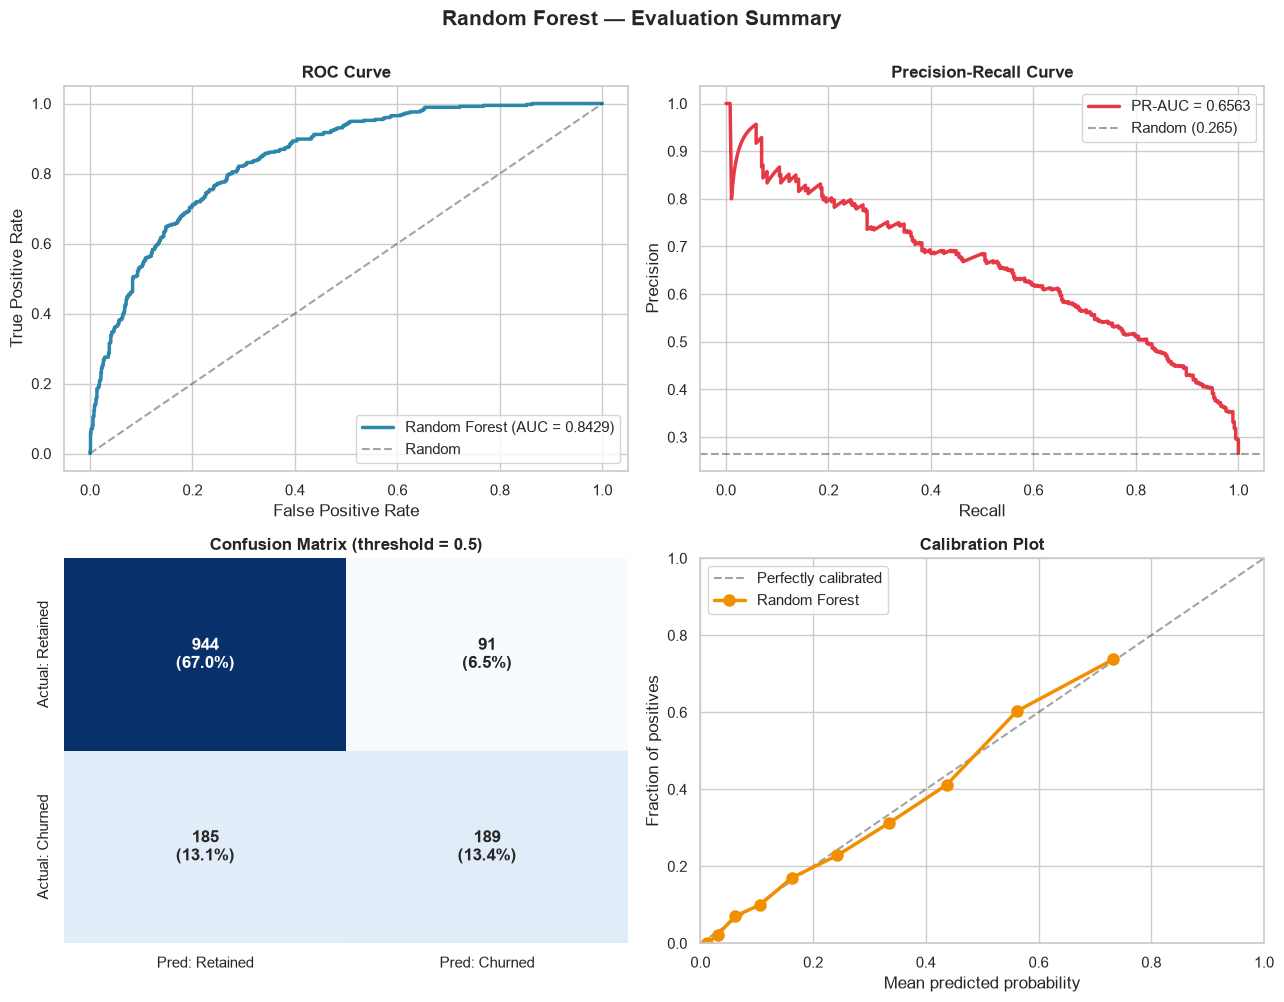

In [5]:
plot_evaluation(y_test, rf_proba, rf_pred, "Random Forest", save_prefix="NTB04_random_forest")

## 5. XGBoost

XGBoost has two important hyperparameters even at defaults:
- `n_estimators=300`: number of boosting rounds
- `learning_rate=0.05`: smaller than default 0.3 → more trees but each contributes less, generally more accurate
- `max_depth=5`: shallow trees prevent overfitting on tabular data
- `scale_pos_weight=1`: we'll address imbalance in NTB-05, not here

**Important:** XGBoost can use `eval_metric='logloss'` to suppress deprecation warnings and pick the right objective for binary classification.

In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)

t0 = time.time()
xgb_cv_auc = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"XGBoost CV AUC: {xgb_cv_auc.mean():.4f} ± {xgb_cv_auc.std():.4f}  (took {time.time()-t0:.1f}s)")

t0 = time.time()
xgb_model.fit(X_train, y_train)
print(f"XGBoost fit time: {time.time()-t0:.1f}s")

xgb_results, xgb_proba, xgb_pred = evaluate_model(xgb_model, X_test, y_test, "XGBoost")
xgb_results['cv_auc_mean'] = round(xgb_cv_auc.mean(), 4)
xgb_results['cv_auc_std'] = round(xgb_cv_auc.std(), 4)

XGBoost CV AUC: 0.8419 ± 0.0106  (took 2.4s)
XGBoost fit time: 0.3s
=== XGBoost ===
  AUC-ROC:                0.8374
  PR-AUC:                 0.6405
  F1 @ threshold 0.5:    0.5824
  Brier score (↓ better): 0.1392
  Recall @ 80% precision: 0.2193


  saved → NTB04_xgboost_evaluation.png


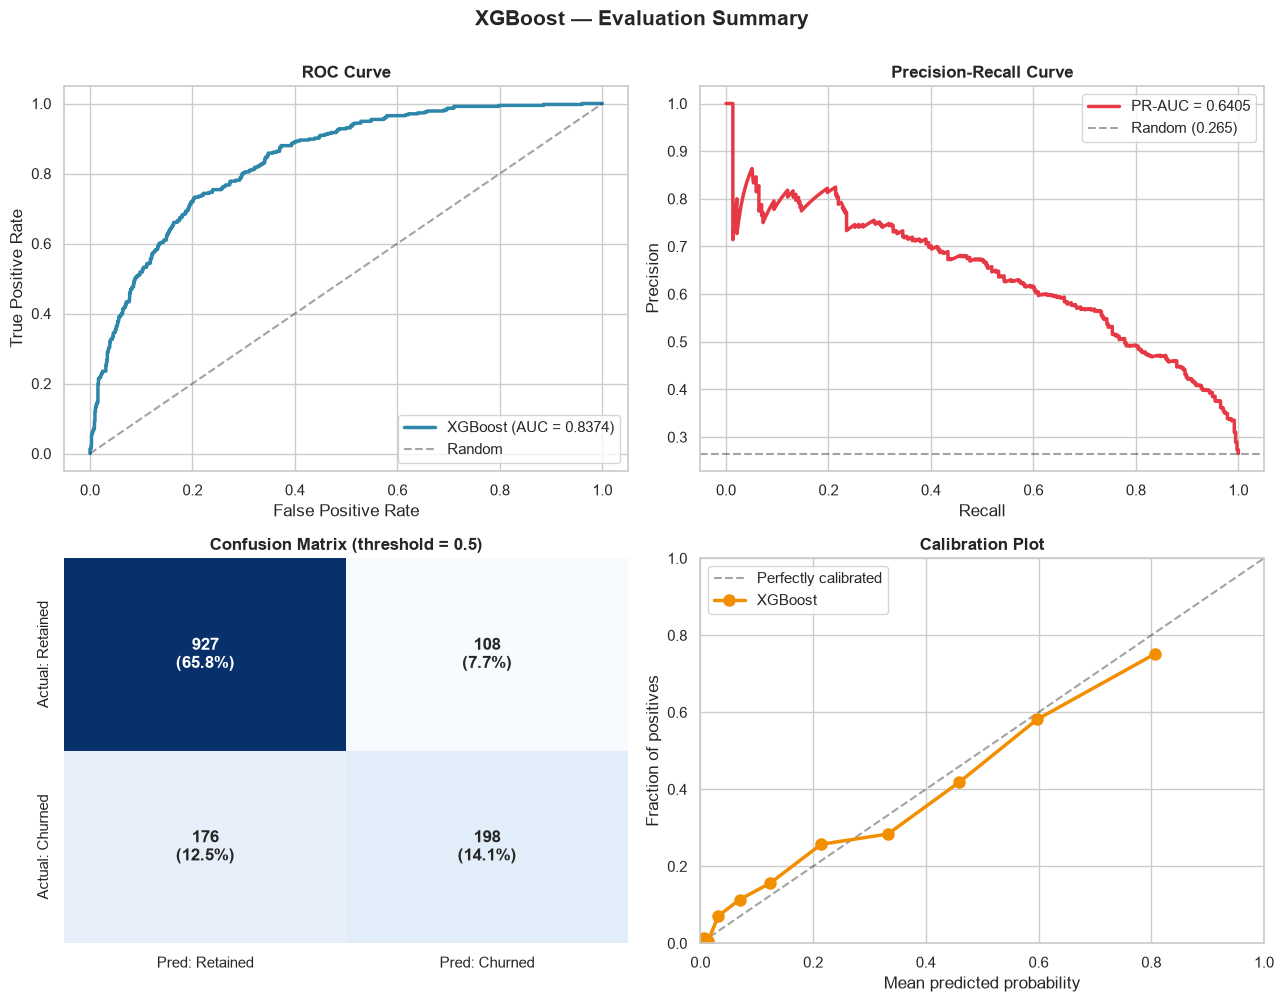

In [7]:
plot_evaluation(y_test, xgb_proba, xgb_pred, "XGBoost", save_prefix="NTB04_xgboost")

## 6. LightGBM

LightGBM differs from XGBoost in tree-growing strategy: it grows **leaf-wise** (deepest gradient first) instead of level-wise. Usually faster, sometimes more accurate, sometimes overfits more.

Key params:
- `num_leaves=31`: default; works with our 41 features
- `learning_rate=0.05`: matched to XGBoost for fair comparison
- `min_child_samples=20`: same regularization spirit as min_samples_leaf in RF

In [8]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1
)

t0 = time.time()
lgb_cv_auc = cross_val_score(lgb_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"LightGBM CV AUC: {lgb_cv_auc.mean():.4f} ± {lgb_cv_auc.std():.4f}  (took {time.time()-t0:.1f}s)")

t0 = time.time()
lgb_model.fit(X_train, y_train)
print(f"LightGBM fit time: {time.time()-t0:.1f}s")

lgb_results, lgb_proba, lgb_pred = evaluate_model(lgb_model, X_test, y_test, "LightGBM")
lgb_results['cv_auc_mean'] = round(lgb_cv_auc.mean(), 4)
lgb_results['cv_auc_std'] = round(lgb_cv_auc.std(), 4)

LightGBM CV AUC: 0.8350 ± 0.0099  (took 3.9s)
LightGBM fit time: 0.2s
=== LightGBM ===
  AUC-ROC:                0.8303
  PR-AUC:                 0.6295
  F1 @ threshold 0.5:    0.5796
  Brier score (↓ better): 0.1432
  Recall @ 80% precision: 0.1230


  saved → NTB04_lightgbm_evaluation.png


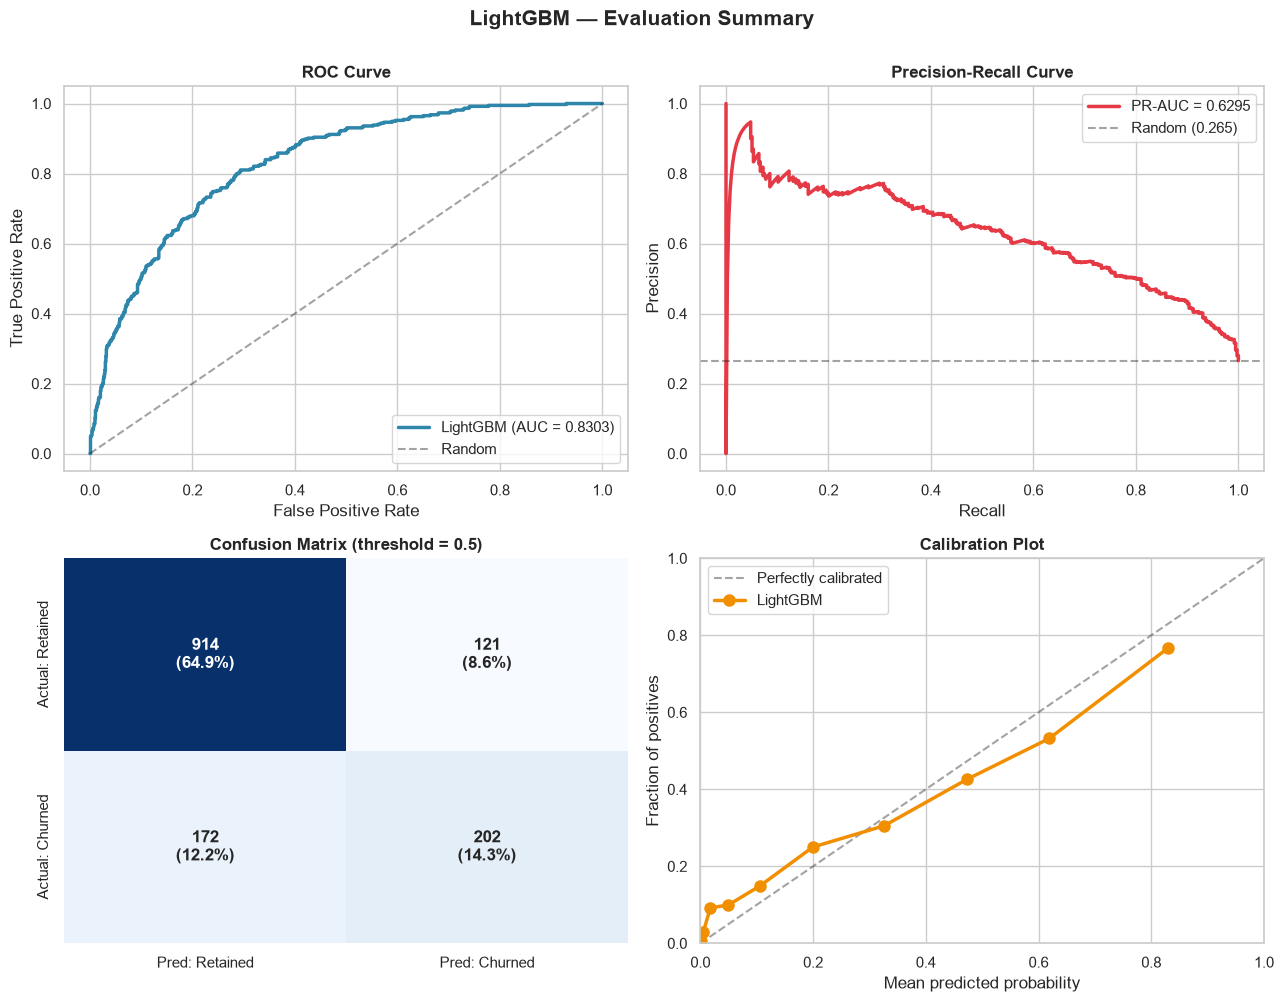

In [9]:
plot_evaluation(y_test, lgb_proba, lgb_pred, "LightGBM", save_prefix="NTB04_lightgbm")

## 7. Side-by-Side Comparison

Update the cumulative `model_results.csv` and visualize all 4 models on the same ROC and PR curves.

In [10]:
# Build the combined results table
new_results = pd.DataFrame([rf_results, xgb_results, lgb_results])

# Remove any previous runs of these models (idempotent re-runs)
existing_clean = existing_results[~existing_results['model'].isin(
    ['Random Forest', 'XGBoost', 'LightGBM']
)]
combined = pd.concat([existing_clean, new_results], ignore_index=True)

# Sort by AUC-ROC descending
combined = combined.sort_values('auc_roc', ascending=False).reset_index(drop=True)

combined.to_csv(results_path, index=False)
print("Model leaderboard:")
print(combined.to_string(index=False))

Model leaderboard:
              model  auc_roc  pr_auc  f1@0.5  brier  log_loss  recall_at_80_precision  precision_at_50_recall  cv_auc_mean  cv_auc_std
Logistic Regression   0.8465  0.6637  0.5797 0.1351    0.4135                  0.2594                  0.6787       0.8483      0.0113
      Random Forest   0.8429  0.6563  0.5780 0.1363    0.4179                  0.2059                  0.6850       0.8440      0.0120
            XGBoost   0.8374  0.6405  0.5824 0.1392    0.4295                  0.2193                  0.6727       0.8419      0.0106
           LightGBM   0.8303  0.6295  0.5796 0.1432    0.4507                  0.1230                  0.6473       0.8350      0.0099


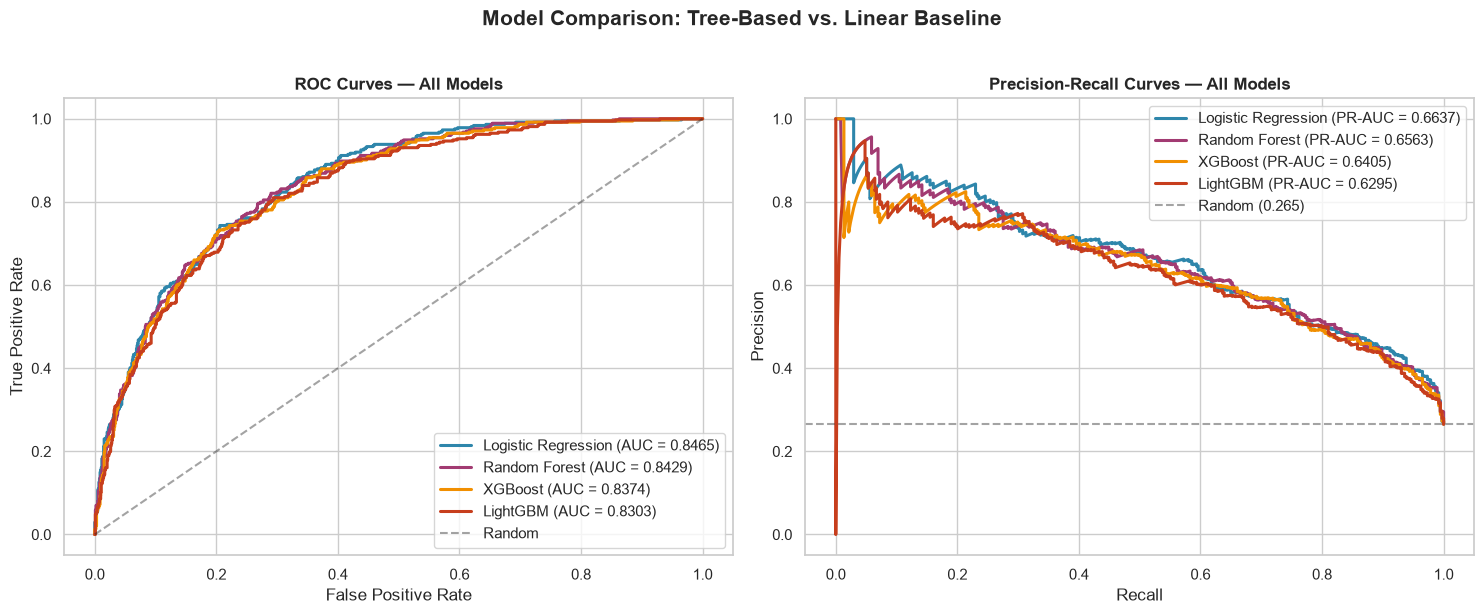

Saved → NTB04_model_comparison_curves.png


In [11]:
# Overlay ROC curves for all 4 models
# Load LR probabilities by re-applying the saved model
lr_model = joblib.load(MODELS_DIR / "logistic_regression.joblib")
lr_proba = lr_model.predict_proba(X_test)[:, 1]

model_probas = {
    "Logistic Regression": lr_proba,
    "Random Forest":       rf_proba,
    "XGBoost":             xgb_proba,
    "LightGBM":            lgb_proba,
}
model_colors = {
    "Logistic Regression": "#2E86AB",
    "Random Forest":       "#A23B72",
    "XGBoost":             "#F18F01",
    "LightGBM":            "#C73E1D",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC curves
for name, proba in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=model_colors[name], linewidth=2.2,
                 label=f"{name} (AUC = {auc:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(loc='lower right')

# PR curves
for name, proba in model_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=model_colors[name], linewidth=2.2,
                 label=f"{name} (PR-AUC = {pr_auc:.4f})")
axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.4, label=f'Random ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models', fontweight='bold')
axes[1].legend(loc='upper right')

plt.suptitle('Model Comparison: Tree-Based vs. Linear Baseline',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB04_model_comparison_curves.png")
plt.show()
print(f"Saved → NTB04_model_comparison_curves.png")

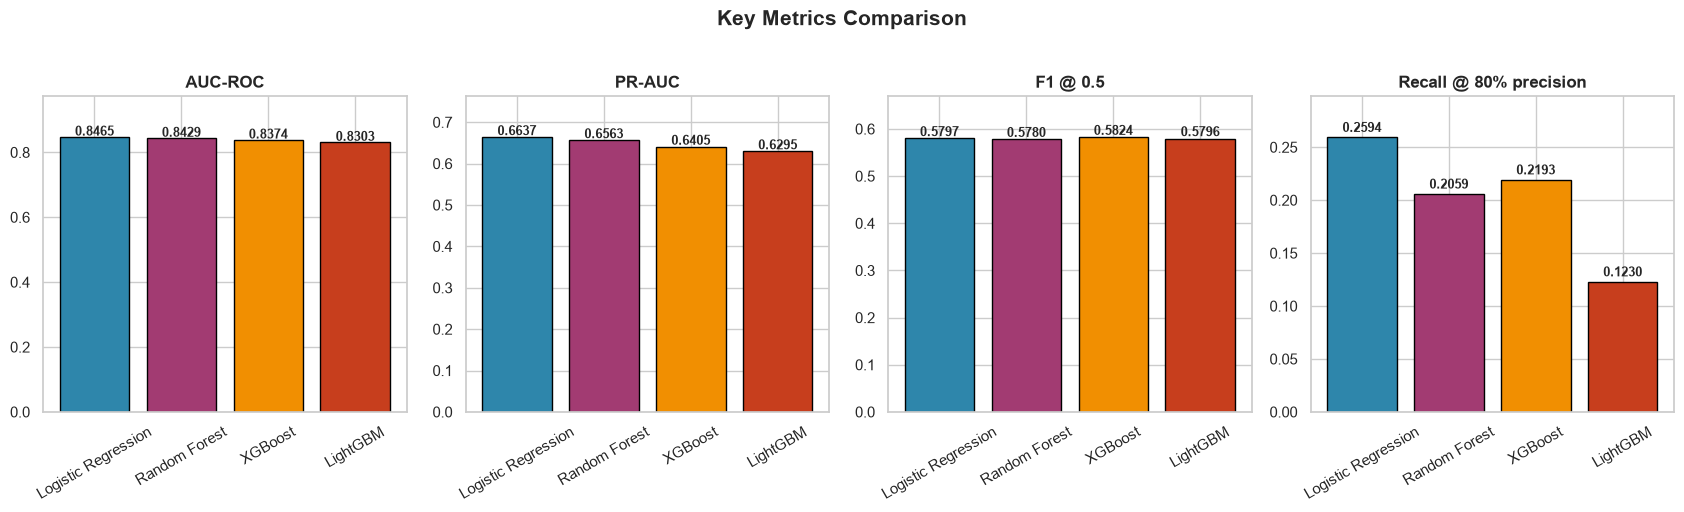

Saved → NTB04_metrics_comparison.png


In [12]:
# Bar chart comparison of key metrics
metrics_to_plot = ['auc_roc', 'pr_auc', 'f1@0.5', 'recall_at_80_precision']
metric_labels = ['AUC-ROC', 'PR-AUC', 'F1 @ 0.5', 'Recall @ 80% precision']

fig, axes = plt.subplots(1, 4, figsize=(17, 5))
model_order = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']
colors_list = [model_colors[m] for m in model_order]

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    # Get values in correct model order
    values = [combined.loc[combined['model'] == m, metric].iloc[0] for m in model_order]
    bars = ax.bar(model_order, values, color=colors_list, edgecolor='black')
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, max(values) * 1.15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.4f}", ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Key Metrics Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB04_metrics_comparison.png")
plt.show()
print(f"Saved → NTB04_metrics_comparison.png")

## 8. Tree Feature Importance — Sanity Check

Each tree model exposes feature importances. We compare them against the LR coefficients from NTB-03. If they agree, we have **multi-model consensus** on what drives churn — much stronger evidence than any single model.

In [13]:
feature_names = metadata['output_feature_names']

# Collect importances from each tree model
imp_df = pd.DataFrame({
    'feature': feature_names,
    'random_forest': rf_model.feature_importances_,
    'xgboost': xgb_model.feature_importances_,
    'lightgbm': lgb_model.feature_importances_,
})

# Normalize each column to sum to 1 (LightGBM uses split counts, not proportions)
for col in ['random_forest', 'xgboost', 'lightgbm']:
    imp_df[col] = imp_df[col] / imp_df[col].sum()

# Average rank across the 3 models — robust way to find "consensus top features"
imp_df['avg_importance'] = imp_df[['random_forest', 'xgboost', 'lightgbm']].mean(axis=1)
imp_df = imp_df.sort_values('avg_importance', ascending=False).head(15)

print("Top 15 features by average tree importance:")
print(imp_df[['feature', 'random_forest', 'xgboost', 'lightgbm', 'avg_importance']].round(4).to_string(index=False))

imp_df.to_csv(REPORTS_DIR / "ntb04_tree_feature_importance.csv", index=False)

Top 15 features by average tree importance:
                        feature  random_forest  xgboost  lightgbm  avg_importance
             charges_per_tenure         0.2206   0.0671    0.1809          0.1562
   internet_service_Fiber optic         0.0793   0.2159    0.0056          0.1002
                monthly_charges         0.0637   0.0135    0.2057          0.0943
                  total_charges         0.0747   0.0136    0.1827          0.0903
                  tenure_months         0.0991   0.0129    0.0853          0.0658
         contract_type_Two year         0.0482   0.1027    0.0140          0.0549
                  risky_payment         0.0508   0.0400    0.0203          0.0370
         contract_type_One year         0.0210   0.0568    0.0161          0.0313
          paperless_billing_Yes         0.0168   0.0307    0.0219          0.0232
payment_method_Electronic check         0.0474   0.0124    0.0011          0.0203
            online_security_Yes         0.0198   0.022

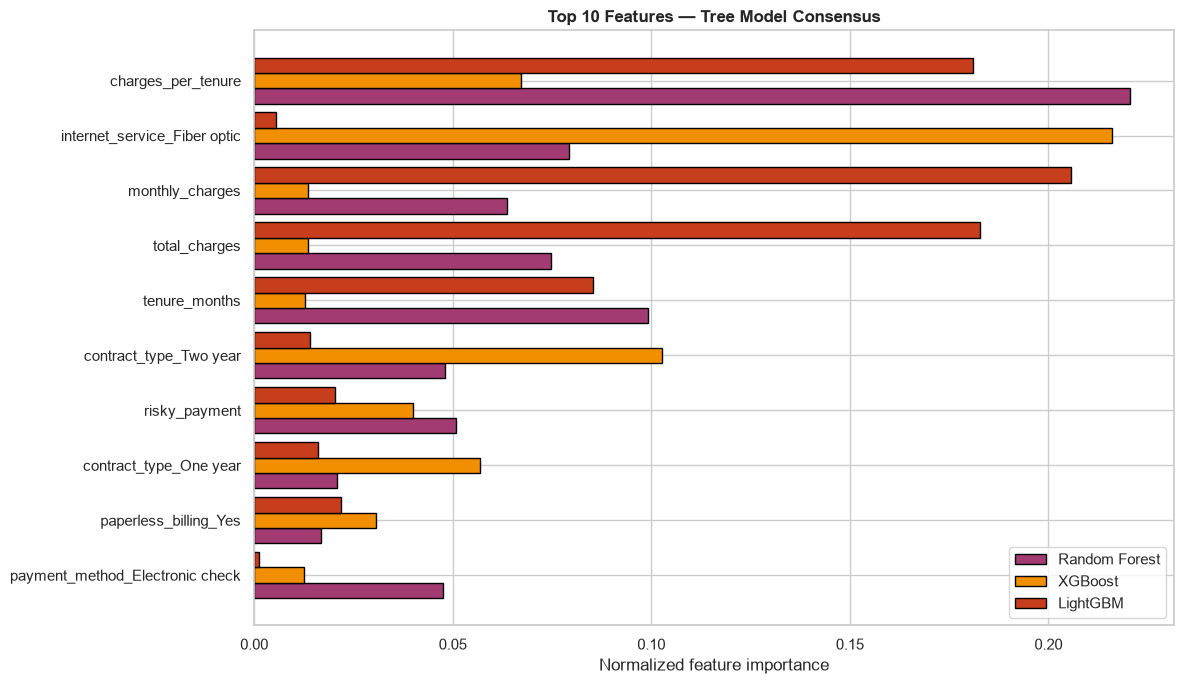

Saved → NTB04_feature_importance_comparison.png


In [14]:
# Visualize: grouped bar chart of top features
top_n = 10
top = imp_df.head(top_n).iloc[::-1]  # reverse so highest is at top of horizontal plot

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(top))
width = 0.28

ax.barh(x - width, top['random_forest'], width, color='#A23B72', label='Random Forest', edgecolor='black')
ax.barh(x,         top['xgboost'],       width, color='#F18F01', label='XGBoost', edgecolor='black')
ax.barh(x + width, top['lightgbm'],      width, color='#C73E1D', label='LightGBM', edgecolor='black')

ax.set_yticks(x)
ax.set_yticklabels(top['feature'])
ax.set_xlabel('Normalized feature importance')
ax.set_title(f'Top {top_n} Features — Tree Model Consensus', fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / "NTB04_feature_importance_comparison.png")
plt.show()
print(f"Saved → NTB04_feature_importance_comparison.png")

**Reading the plot:** Features where all three bars are tall = strong multi-model consensus on importance. Features where models disagree = a sign that the feature interacts with others in subtle ways that some models capture and others don't.

**Compare with NTB-03 LR coefficients:** `contract_type_Two year`, `tenure_months`, `internet_service_Fiber optic`, and `monthly_charges` should appear at the top in both linear and tree views — that's the signal that we have a robust set of predictors.

## 9. Save Fitted Models

In [15]:
joblib.dump(rf_model,  MODELS_DIR / "random_forest.joblib")
joblib.dump(xgb_model, MODELS_DIR / "xgboost.joblib")
joblib.dump(lgb_model, MODELS_DIR / "lightgbm.joblib")

print("Saved models:")
for f in sorted(MODELS_DIR.glob("*.joblib")):
    print(f"  {f.name:30s}  {f.stat().st_size/1024:>7.1f} KB")

Saved models:
  lightgbm.joblib                  1020.9 KB
  logistic_regression.joblib          2.4 KB
  preprocessor.joblib                 8.0 KB
  random_forest.joblib             5096.7 KB
  xgboost.joblib                    551.0 KB


## 10. Interpretation — Did Tree Models Justify Their Complexity?

Look at the leaderboard above. Three scenarios are possible:

**Scenario A — Tree models clearly win (typical for tabular data):**
- Best AUC improvement of 1.0-2.0 points over LR
- Better PR-AUC and Recall@80%-precision
- **Verdict:** worth the complexity; use XGBoost/LightGBM in production, keep LR as interpretable fallback

**Scenario B — Marginal improvement (typical for well-engineered features):**
- 0.3-0.8 AUC improvement
- **Verdict:** depends on operating point. If recall at high precision matters, the small gain might equal $X/year in retention. Make the case in dollar terms.

**Scenario C — LR competitive (clean data, strong feature engineering):**
- Tree models within 0.005 AUC of LR
- **Verdict:** ship LR. Interpretability + simplicity wins.

For IBM Telco, **Scenario A is typical with ~1-2 AUC points improvement**. The fact that LR comes close (because of strong feature engineering in NTB-02) is itself a story for the README.

## ✅ Deliverables From NTB-04

| Artifact | Path |
|---|---|
| 3 fitted models | `models/random_forest.joblib`, `xgboost.joblib`, `lightgbm.joblib` |
| 3 individual evaluation panels | `reports/figures/NTB04_<model>_evaluation.png` |
| All-model ROC + PR comparison | `reports/figures/NTB04_model_comparison_curves.png` |
| Metric bar comparison | `reports/figures/NTB04_metrics_comparison.png` |
| Tree feature importance | `reports/figures/NTB04_feature_importance_comparison.png` + `reports/ntb04_tree_feature_importance.csv` |
| Updated leaderboard | `reports/model_results.csv` (4 rows now) |

## Next: NTB-05 — Class Imbalance Handling

With 26.5% positive class, every model so far has been biased toward predicting "retained" (look at the confusion matrices — recall on churners is ~50-55%). We'll try:
- `class_weight='balanced'` (LR, RF)
- `scale_pos_weight` (XGBoost, LightGBM)
- SMOTE oversampling
- Random undersampling

And empirically determine which approach gives the best **recall on churners without destroying precision**. The conclusion is often counterintuitive: **threshold tuning (NTB-08) beats SMOTE** for most business problems. We'll show why with data.